In [1]:
from palmerpenguins import load_penguins
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np

data = load_penguins()
filename = "https://raw.githubusercontent.com/OpenClassrooms-Student-Center/8063076-Initiez-vous-au-Machine-Learning/master/data/palmer_penguins_openclassrooms.csv"
df = pd.read_csv(filename)

display(data.head())

# Liste des variables
variables_x = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']
y = df['body_mass_g']

# Boucle pour chaque régression linéaire
for variable in variables_x:
    X = df[[variable]].values.reshape(-1, 1)

    reg = LinearRegression()
    reg.fit(X, y)

    print(f"Régression avec {variable} - R² = {reg.score(X, y):.4f}")

/usr/local/lib/python3.13/site-packages/palmerpenguins/penguins.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


Régression avec bill_length_mm - R² = 0.3475
Régression avec bill_depth_mm - R² = 0.2228
Régression avec flipper_length_mm - R² = 0.7621


# Question 2

In [9]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error
scaler = MinMaxScaler()

X = scaler.fit_transform(df[['bill_length_mm','bill_depth_mm','flipper_length_mm']])
y = df['body_mass_g']

reg = LinearRegression()
reg.fit(X, y)

y_pred = reg.predict(X)

mse = mean_squared_error(y, y_pred)
rmse = root_mean_squared_error(y, y_pred)
mape = mean_absolute_percentage_error(y, y_pred)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")





MSE: 152597.33274339672
RMSE: 390.63708572458495
MAPE: 0.07718264712272083


# Question 3

In [3]:
scaler = MinMaxScaler()
reg = LinearRegression()
for espece in ['Adelie', 'Gentoo', 'Chinstrap']:
    df2 = df[df.species == espece].copy()
    y = df2['body_mass_g']
    X = scaler.fit_transform(df2[['bill_length_mm','bill_depth_mm','flipper_length_mm']])
    reg.fit(X, y)
    print("--\n",espece, reg.score(X, y))

    y_pred = reg.predict(X)
    
    mse = mean_squared_error(y, y_pred)
    rmse = root_mean_squared_error(y, y_pred)
    mape = mean_absolute_percentage_error(y, y_pred)
    
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"MAPE: {mape}")

--
 Adelie 0.5064249444393831
MSE: 103103.77927187756
RMSE: 321.0977721378296
MAPE: 0.0688582880470465
--
 Gentoo 0.6280736371428204
MSE: 92745.44334404985
RMSE: 304.541365571329
MAPE: 0.04719861757681761
--
 Chinstrap 0.50381439825875
MSE: 72215.44695584575
RMSE: 268.72931912213403
MAPE: 0.056609766769789266


# Question 4

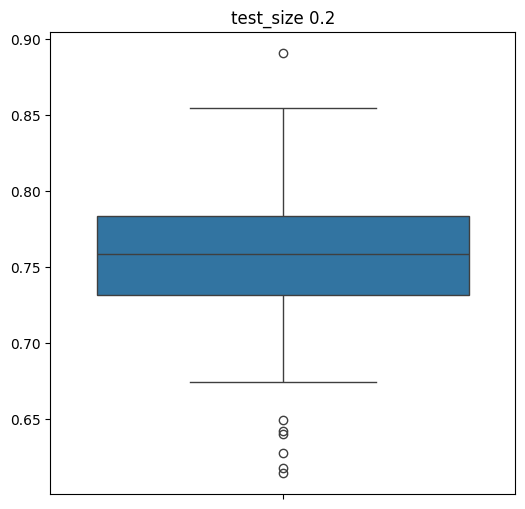

In [4]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

test_size = 0.2
scaler = MinMaxScaler()
y = df['body_mass_g']
X = scaler.fit_transform(df[['bill_length_mm','bill_depth_mm','flipper_length_mm']])
reg = LinearRegression()

score = []

for random_state in np.arange(200):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
  reg.fit(X_train, y_train)
  #print("--\n",test_size, reg.score(X_test, y_test))
  score.append(reg.score(X_test, y_test))

import seaborn as sns
fig = plt.figure(figsize=(6, 6))
sns.boxplot(score)
plt.title(f"test_size {test_size}")
plt.show()

# Question 5

In [10]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

filename = "https://raw.githubusercontent.com/OpenClassrooms-Student-Center/8063076-Initiez-vous-au-Machine-Learning/master/data/palmer_penguins.csv"
data = pd.read_csv(filename)

data.loc[data.sex == 'male', 'sex'] = 0
data.loc[data.sex == 'female', 'sex'] = 1
data.dropna(inplace=True)
data['sex'] = data.sex.astype('int')
data['sex']

data['sex'].value_counts()

sex
0    168
1    165
Name: count, dtype: int64

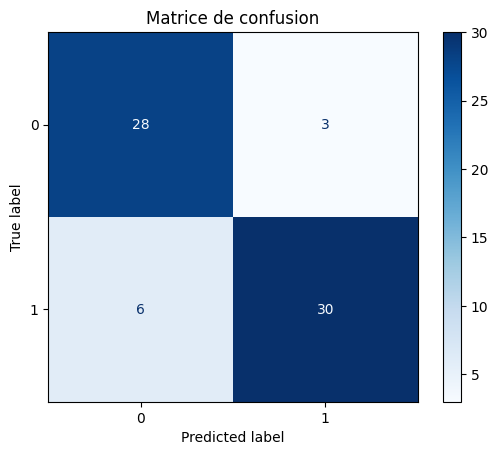

In [11]:
scaler = MinMaxScaler()
y = data['sex'].values
X = scaler.fit_transform(data[['bill_length_mm','bill_depth_mm','flipper_length_mm', 'body_mass_g']])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

clf = LogisticRegression(random_state = 42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)
confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

from sklearn.metrics import ConfusionMatrixDisplay, recall_score, precision_score

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap='Blues')
plt.title("Matrice de confusion")
plt.show()

In [12]:
print('recall = '+str(recall_score(y_test, y_pred)))
print('precision ='+ str(precision_score(y_test, y_pred)))

recall = 0.8333333333333334
precision =0.9090909090909091


# Question 7

In [14]:
y_proba = clf.predict_proba(X_test)[:,1]
y_pred_03 = [ 0 if value < 0.3 else 1 for value in y_proba ]
y_pred_07 = [ 0 if value < 0.7 else 1 for value in y_proba ]

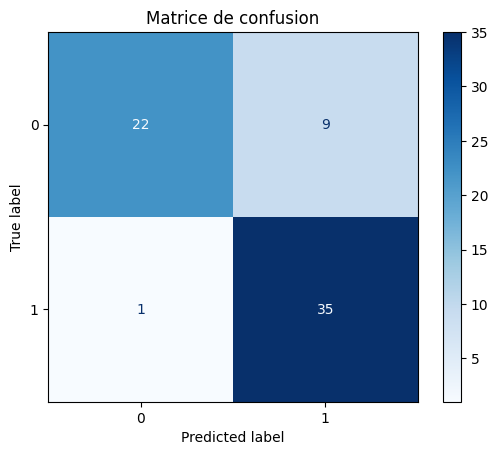

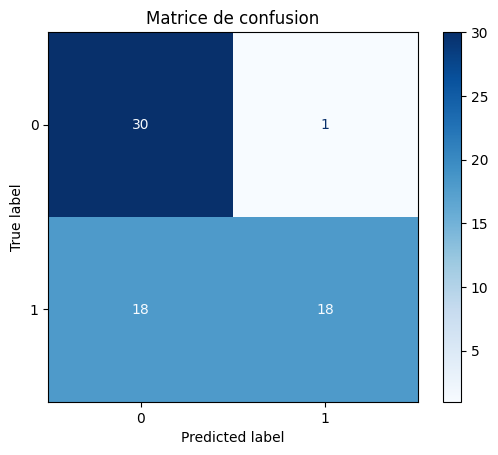

In [15]:
cm = confusion_matrix(y_test, y_pred_03)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap='Blues')
plt.title("Matrice de confusion")
plt.show()

cm = confusion_matrix(y_test, y_pred_07)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap='Blues')
plt.title("Matrice de confusion")
plt.show()

# Question 8 

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Split pour X1
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y, test_size=0.20, random_state=42)
clf1 = LogisticRegression(random_state=42)
clf1.fit(X1_train, y1_train)
y1_pred = clf1.predict(X1_test)

# Split pour X2
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.20, random_state=42)
clf2 = LogisticRegression(random_state=42)
clf2.fit(X2_train, y2_train)
y2_pred = clf2.predict(X2_test)

# Matrices de confusion
cm1 = confusion_matrix(y1_test, y1_pred, labels=[1, 2, 3])
cm2 = confusion_matrix(y2_test, y2_pred, labels=[1, 2, 3])

# Affichage côte à côte
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=['Chinstrap', 'Gentoo', 'Adelie'])
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("Avec body_mass_g")

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['Chinstrap', 'Gentoo', 'Adelie'])
disp2.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title("Sans body_mass_g")

plt.tight_layout()
plt.show()

# Question 9